In [1]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, 
                                     GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, Reshape, Layer, Lambda, Add, Multiply, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ================= 1. 物理参数与全局定义 =================
FS = 200000 
TYPE_NAMES = ["SingleTone", "Chirp", "Pulse", "HoppingJam", "NoiseFM", "NoiseAM", "Comb", "Mixed", "Normal"]
TRUTH_MAP = {
    0: [500, 0], 1: [60000, 0], 2: [45000, 0], 3: [85000, 0],
    4: [70000, 0], 5: [35000, 0], 6: [65000, 0], 7: [80000, 0], 8: [0, 0]
}

# ================= 2. 核心自定义层 =================
class ResNetBlock1D(Layer):
    def __init__(self, filters, kernel_size, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = Conv1D(filters, kernel_size, strides=strides, padding='same', use_bias=False)
        self.bn1 = BatchNormalization()
        self.conv2 = Conv1D(filters, kernel_size, padding='same', use_bias=False)
        self.bn2 = BatchNormalization()
        self.shortcut = Conv1D(filters, 1, strides=strides, padding='same') if strides != 1 else Lambda(lambda x: x)
    def call(self, inputs):
        x = tf.nn.relu(self.bn1(self.conv1(inputs)))
        x = self.bn2(self.conv2(x))
        return tf.nn.relu(Add()([x, self.shortcut(inputs)]))

class ResNetBlock2D(Layer):
    def __init__(self, filters, kernel_size, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = Conv2D(filters, kernel_size, strides=strides, padding='same', use_bias=False)
        self.bn1 = BatchNormalization()
        self.conv2 = Conv2D(filters, kernel_size, padding='same', use_bias=False)
        self.bn2 = BatchNormalization()
        self.shortcut = Conv2D(filters, 1, strides=strides, padding='same') if strides != 1 else Lambda(lambda x: x)
    def call(self, inputs):
        x = tf.nn.relu(self.bn1(self.conv1(inputs)))
        x = self.bn2(self.conv2(x))
        return tf.nn.relu(Add()([x, self.shortcut(inputs)]))

class EfficientTemporalEncoder(Layer):
    def __init__(self, filters=64, **kwargs):
        super().__init__(**kwargs)
        self.depth_conv = Conv1D(filters, 3, padding='same', groups=filters, use_bias=False)
        self.bn = BatchNormalization()
        self.pool = GlobalAveragePooling1D()
    def call(self, inputs):
        x = tf.nn.relu(self.bn(self.depth_conv(inputs)))
        return self.pool(Add()([x, inputs]))

# 🌟 核心修复区 1：支持 (1024, 2) 双通道的统计特征提取
def extract_stat_features(x):
    mu = tf.reduce_mean(x, axis=1) # Shape: (Batch, 2)
    sigma = tf.math.reduce_std(x, axis=1) 
    rms = tf.sqrt(tf.reduce_mean(tf.square(x), axis=1)) 
    kurt = tf.reduce_mean(tf.pow((x - tf.expand_dims(mu, 1)) / (tf.expand_dims(sigma, 1) + 1e-8), 4), axis=1) - 3.0
    return tf.concat([mu, sigma, rms, kurt], axis=1) # Shape: (Batch, 8)

# 🌟 核心修复区 2：支持双通道复数 STFT 的频域预处理
# 🌟 核心修复区 2：支持双通道独立 STFT 的频域预处理（解决 complex64 报错）
def complex_stft_layer(x):
    # 分别提取 I 路 (实部) 和 Q 路 (虚部)
    I_channel = x[..., 0]
    Q_channel = x[..., 1]
    
    # 分别进行 STFT 变换 (此时输入的是 float32 实数，完美符合 TF 要求)
    stft_I = tf.signal.stft(I_channel, frame_length=128, frame_step=64)
    stft_Q = tf.signal.stft(Q_channel, frame_length=128, frame_step=64)
    
    # 获取频谱幅度 (此时恢复为 float32)
    mag_I = tf.abs(stft_I)
    mag_Q = tf.abs(stft_Q)
    
    # 将 I 和 Q 的频谱在最后一个维度堆叠，形成 2 通道的 "频谱图"
    # 输出形状变为 (Batch, time_frames, freq_bins, 2)
    return tf.stack([mag_I, mag_Q], axis=-1)

class PLELayer(Layer):
    def __init__(self, num_tasks=3, num_shared=2, num_specific=1, expert_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.num_tasks, self.num_shared, self.num_specific, self.expert_dim = num_tasks, num_shared, num_specific, expert_dim
    def build(self, input_shape):
        self.shared_experts = [Dense(self.expert_dim, activation='relu') for _ in range(self.num_shared)]
        self.specific_experts = [[Dense(self.expert_dim, activation='relu') for _ in range(self.num_specific)] for _ in range(self.num_tasks)]
        self.gates = [Dense(self.num_shared + self.num_specific, activation='softmax') for _ in range(self.num_tasks)]
    def call(self, inputs):
        shared_outs = [ex(inputs) for ex in self.shared_experts]
        task_outputs = []
        for t in range(self.num_tasks):
            spec_outs = [ex(inputs) for ex in self.specific_experts[t]]
            all_experts = tf.stack(shared_outs + spec_outs, axis=1)
            gate_weights = tf.expand_dims(self.gates[t](inputs), axis=-1)
            task_outputs.append(tf.reduce_sum(all_experts * gate_weights, axis=1))
        return task_outputs

# ================= 3. 模型组装 (MBF-PLENet-Pro) =================
def build_mbf_plenet_pro(L=1024, num_classes=9):
    # 🌟 核心修复区 3：输入维度从 (L,) 升级为 (L, 2)
    inputs = Input(shape=(L, 2), name='input_signal')
    
    # --- MBF 四分支 ---
    f_time = ResNetBlock1D(64, 7, strides=2)(inputs)
    f_time = GlobalAveragePooling1D()(f_time)
    
    x_f = Lambda(complex_stft_layer)(inputs)
    f_freq = ResNetBlock2D(64, (3,3), strides=2)(x_f)
    f_freq = GlobalAveragePooling2D()(f_freq)
    
    x_temp = Conv1D(64, 1, padding='same', activation='relu')(inputs)
    f_temporal = EfficientTemporalEncoder(filters=64)(x_temp)
    
    f_stat = Dense(64, activation='relu')(Lambda(extract_stat_features)(inputs))

    # --- 融合与输出 ---
    branches = [f_time, f_freq, f_temporal, f_stat]
    weights = [Dense(1, activation='sigmoid')(b) for b in branches]
    f_fused = Add()([Multiply()([b, w]) for b, w in zip(branches, weights)])
    f_fused = Dense(256, activation='relu')(f_fused) 
    f_fused = Dropout(0.4)(f_fused) 
    f_fused = Dense(128, activation='relu')(f_fused)

    ple_tasks = PLELayer(num_tasks=3, num_shared=2, num_specific=1, expert_dim=128)(f_fused)
    
    det_out = Dense(1, activation='sigmoid', name='det_out')(ple_tasks[0])
    cls_feat = Dense(128, activation='relu')(ple_tasks[1])
    cls_feat = Dropout(0.2)(cls_feat)
    cls_out = Dense(num_classes, activation='softmax', name='cls_out')(cls_feat)
    reg_out = Dense(3, activation='linear', name='reg_out')(ple_tasks[2])

    model = Model(inputs, [det_out, cls_out, reg_out], name='MBF-PLENet-Pro')
    model.compile(optimizer=Adam(learning_rate=3e-4),
                  loss={'det_out': 'binary_crossentropy', 'cls_out': 'sparse_categorical_crossentropy', 'reg_out': 'mse'},
                  loss_weights={'det_out': 0.8, 'cls_out': 5.0, 'reg_out': 0.5},
                  metrics={'det_out': 'accuracy', 'cls_out': 'accuracy'})
    return model

# ================= 4. 数据加载与主程序 =================
def load_v5_dataset(path):
    all_x, all_y, all_j = [], [], []
    files = sorted([f for f in os.listdir(path) if f.endswith('_X.npy')])
    for fx in files:
        match = re.search(r'jnr(-?\d+)', fx)
        jnr = float(match.group(1)) if match else 0.0
        x = np.load(os.path.join(path, fx))
        y = np.load(os.path.join(path, fx.replace('_X.npy', '_Y.npy')))
        
        # 🌟 核心修复区 4：删除了导致灾难的单通道截断代码！
        # 完整保留 x 的 (Batch, 1024, 2) 形状
        
        all_x.append(x); all_y.append(y); all_j.append(np.full(len(y), jnr))
    
    X, Y, J = np.vstack(all_x), np.concatenate(all_y), np.concatenate(all_j)
    bw_norm = np.array([TRUTH_MAP[l][0]/FS for l in Y])
    fc_norm = np.array([TRUTH_MAP[l][1]/(FS/2) for l in Y])
    jnr_norm = np.clip((10**(J/10) - 0.1) / (1000 - 0.1), 0, 1)
    params = np.stack([bw_norm, fc_norm, jnr_norm], axis=1).astype(np.float32)
    
    return train_test_split(X, (Y<8).astype(float), Y, params, J, test_size=0.3, stratify=Y, random_state=42)

def main():
    root_path = "/root/autodl-tmp/validate/0218/Perception/dataset_final_ready_v5"
    save_dir = "./models/MBF_PLENet_Pro"
    os.makedirs(save_dir, exist_ok=True)
    
    print("🔥 正在加载双通道纯净数据集...")
    X_train, X_tmp, d_train, d_tmp, y_train, y_tmp, p_train, p_tmp, j_train, j_tmp = load_v5_dataset(root_path)
    X_val, X_test, d_val, d_test, y_val, y_test, p_val, p_test, j_val, j_test = \
        train_test_split(X_tmp, d_tmp, y_tmp, p_tmp, j_tmp, test_size=1/3, stratify=y_tmp, random_state=42)
    
    model = build_mbf_plenet_pro(L=1024, num_classes=9)
    
    callbacks = [
        EarlyStopping(monitor='val_cls_out_accuracy', patience=10, restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_cls_out_accuracy', factor=0.5, patience=4, mode='max'),
        ModelCheckpoint(os.path.join(save_dir, "best_pro_model.h5"), save_best_only=True, monitor='val_cls_out_accuracy', mode='max')
    ]
    
    print("🚀 启动完全体双通道 MBF-PLENet-Pro 训练计划...")
    model.fit(X_train, {'det_out': d_train, 'cls_out': y_train, 'reg_out': p_train},
              validation_data=(X_val, {'det_out': d_val, 'cls_out': y_val, 'reg_out': p_val}),
              epochs=100, batch_size=128, callbacks=callbacks, verbose=1)
              
    print("✅ 训练完成！新权重已保存至: ./models/MBF_PLENet_Pro/best_pro_model.h5")

if __name__ == "__main__":
    main()

2026-05-16 21:04:02.460597: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 21:04:02.520559: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 21:04:03.326074: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


🔥 正在加载双通道纯净数据集...


2026-05-16 21:04:07.706931: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46628 MB memory:  -> device: 0, name: NVIDIA vGPU-48GB, pci bus id: 0000:99:00.0, compute capability: 8.9


🚀 启动完全体双通道 MBF-PLENet-Pro 训练计划...
Epoch 1/100


2026-05-16 21:04:14.558909: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-05-16 21:04:14.576366: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-05-16 21:04:14.988173: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f3f12b48730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-16 21:04:14.988209: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA vGPU-48GB, Compute Capability 8.9
2026-05-16 21:04:15.480745: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-16 21:04:15.572565: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.

745/745 [==============================] - 42s 38ms/step - loss: 6.2720 - det_out_loss: 0.0153 - cls_out_loss: 1.2488 - reg_out_loss: 0.0320 - det_out_accuracy: 0.9997 - cls_out_accuracy: 0.5283 - val_loss: 4.7449 - val_det_out_loss: 1.8413e-04 - val_cls_out_loss: 0.9472 - val_reg_out_loss: 0.0177 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.6588 - lr: 3.0000e-04
Epoch 2/100
745/745 [==============================] - 25s 33ms/step - loss: 4.6008 - det_out_loss: 6.3023e-05 - cls_out_loss: 0.9183 - reg_out_loss: 0.0182 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.6689 - val_loss: 4.2459 - val_det_out_loss: 4.9969e-05 - val_cls_out_loss: 0.8479 - val_reg_out_loss: 0.0128 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.6920 - lr: 3.0000e-04
Epoch 3/100
745/745 [==============================] - 25s 33ms/step - loss: 4.1520 - det_out_loss: 2.0760e-05 - cls_out_loss: 0.8290 - reg_out_loss: 0.0136 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.6954 - val_loss: 3.791

2026-05-16 22:59:04.662247: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 22:59:04.724848: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 22:59:05.527205: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



📦 正在加载原始纯净数据集: /root/autodl-tmp/validate/0218/Perception/dataset_final_ready_v5 ...

🚀 阶段一：基于多普勒物理增强层的终极抗畸变训练...


2026-05-16 22:59:10.312061: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46628 MB memory:  -> device: 0, name: NVIDIA vGPU-48GB, pci bus id: 0000:99:00.0, compute capability: 8.9


Epoch 1/30


2026-05-16 22:59:17.680319: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-05-16 22:59:17.976310: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f611eb01a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-16 22:59:17.976340: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA vGPU-48GB, Compute Capability 8.9
2026-05-16 22:59:18.427191: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-16 22:59:18.430437: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-05-16 22:59:18.682239: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.

745/745 [==============================] - 48s 46ms/step - loss: 6.9212 - det_out_loss: 0.0116 - cls_out_loss: 1.3797 - reg_out_loss: 0.0269 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.4769 - val_loss: 5.8144 - val_det_out_loss: 3.0927e-06 - val_cls_out_loss: 1.1609 - val_reg_out_loss: 0.0195 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.5705 - lr: 3.0000e-04
Epoch 2/30
745/745 [==============================] - 34s 45ms/step - loss: 5.1417 - det_out_loss: 2.9446e-05 - cls_out_loss: 1.0267 - reg_out_loss: 0.0165 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.6201 - val_loss: 4.8504 - val_det_out_loss: 2.3376e-06 - val_cls_out_loss: 0.9687 - val_reg_out_loss: 0.0136 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.6464 - lr: 3.0000e-04
Epoch 3/30
745/745 [==============================] - 31s 41ms/step - loss: 4.6416 - det_out_loss: 1.6601e-05 - cls_out_loss: 0.9270 - reg_out_loss: 0.0129 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.6578 - val_loss: 4.8010 

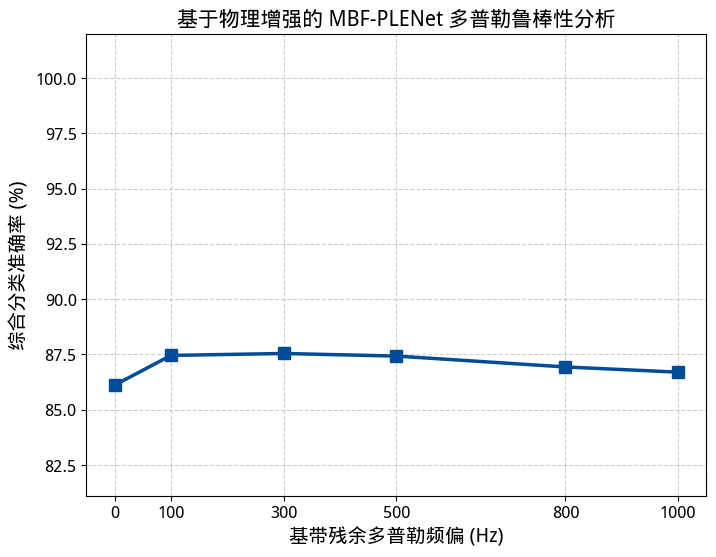

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, 
                                     GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, Reshape, Layer, Lambda, Add, Multiply, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from matplotlib import font_manager as fm

# ================= 0. 配置与中文字体 =================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 'C:/Windows/Fonts/simhei.ttf', '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return
    except: pass
set_chinese_font()

FS = 200000 
TRUTH_MAP = {0: [500, 0], 1: [60000, 0], 2: [45000, 0], 3: [85000, 0], 4: [70000, 0], 5: [35000, 0], 6: [65000, 0], 7: [80000, 0], 8: [0, 0]}

# ================= 1. 物理先验增强层 (核心创新点！) =================
class DopplerAugmentation(Layer):
    """
    在训练阶段动态注入残余多普勒频偏和随机初始相位，
    赋予模型真正的“旋转不变性”！
    """
    def __init__(self, max_fd=1000.0, fs=200000.0, **kwargs):
        super().__init__(**kwargs)
        self.max_fd = max_fd
        self.fs = fs

    def build(self, input_shape):
        L = input_shape[1]
        t = tf.range(L, dtype=tf.float32) / self.fs
        self.t = tf.reshape(t, [1, L])
        super().build(input_shape)

    def call(self, inputs, training=None):
        if training:
            batch_size = tf.shape(inputs)[0]
            # 随机残余频偏 [-max_fd, max_fd]
            fd = tf.random.uniform([batch_size, 1], minval=-self.max_fd, maxval=self.max_fd)
            # 随机初始相位 [0, 2π]
            phase_0 = tf.random.uniform([batch_size, 1], minval=0.0, maxval=2 * np.pi)
            
            phases = 2.0 * np.pi * fd * self.t + phase_0
            cos_p, sin_p = tf.cos(phases), tf.sin(phases)
            
            I, Q = inputs[..., 0], inputs[..., 1]
            I_rot = I * cos_p - Q * sin_p
            Q_rot = I * sin_p + Q * cos_p
            return tf.stack([I_rot, Q_rot], axis=-1)
        return inputs

# ================= 2. 核心特征层与物理复数STFT =================
class ResNetBlock1D(Layer):
    def __init__(self, filters, kernel_size, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = Conv1D(filters, kernel_size, strides=strides, padding='same', use_bias=False)
        self.bn1 = BatchNormalization()
        self.conv2 = Conv1D(filters, kernel_size, padding='same', use_bias=False)
        self.bn2 = BatchNormalization()
        self.shortcut = Conv1D(filters, 1, strides=strides, padding='same') if strides != 1 else Lambda(lambda x: x)
    def call(self, inputs):
        x = tf.nn.relu(self.bn1(self.conv1(inputs)))
        x = self.bn2(self.conv2(x))
        return tf.nn.relu(Add()([x, self.shortcut(inputs)]))

class ResNetBlock2D(Layer):
    def __init__(self, filters, kernel_size, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = Conv2D(filters, kernel_size, strides=strides, padding='same', use_bias=False)
        self.bn1 = BatchNormalization()
        self.conv2 = Conv2D(filters, kernel_size, padding='same', use_bias=False)
        self.bn2 = BatchNormalization()
        self.shortcut = Conv2D(filters, 1, strides=strides, padding='same') if strides != 1 else Lambda(lambda x: x)
    def call(self, inputs):
        x = tf.nn.relu(self.bn1(self.conv1(inputs)))
        x = self.bn2(self.conv2(x))
        return tf.nn.relu(Add()([x, self.shortcut(inputs)]))

class EfficientTemporalEncoder(Layer):
    def __init__(self, filters=64, **kwargs):
        super().__init__(**kwargs)
        self.depth_conv = Conv1D(filters, 3, padding='same', groups=filters, use_bias=False)
        self.bn = BatchNormalization()
        self.pool = GlobalAveragePooling1D()
    def call(self, inputs):
        x = tf.nn.relu(self.bn(self.depth_conv(inputs)))
        return self.pool(Add()([x, inputs]))

def extract_stat_features(x):
    mu = tf.reduce_mean(x, axis=1) 
    sigma = tf.math.reduce_std(x, axis=1) 
    rms = tf.sqrt(tf.reduce_mean(tf.square(x), axis=1)) 
    kurt = tf.reduce_mean(tf.pow((x - tf.expand_dims(mu, 1)) / (tf.expand_dims(sigma, 1) + 1e-8), 4), axis=1) - 3.0
    return tf.concat([mu, sigma, rms, kurt], axis=1)

def true_complex_stft_layer(x):
    """绝对物理正确的复数 STFT 幅度计算，天生不受固定相位影响"""
    I_channel, Q_channel = x[..., 0], x[..., 1]
    stft_I = tf.signal.stft(I_channel, frame_length=128, frame_step=64)
    stft_Q = tf.signal.stft(Q_channel, frame_length=128, frame_step=64)
    # Z_complex = Z_I + j * Z_Q 的数学推导
    real_Z = tf.math.real(stft_I) - tf.math.imag(stft_Q)
    imag_Z = tf.math.imag(stft_I) + tf.math.real(stft_Q)
    # 物理意义上的绝对幅度
    mag = tf.sqrt(tf.square(real_Z) + tf.square(imag_Z) + 1e-8)
    return tf.expand_dims(mag, axis=-1)

class PLELayer(Layer):
    def __init__(self, num_tasks=3, num_shared=2, num_specific=1, expert_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.num_tasks, self.num_shared, self.num_specific, self.expert_dim = num_tasks, num_shared, num_specific, expert_dim
    def build(self, input_shape):
        self.shared_experts = [Dense(self.expert_dim, activation='relu') for _ in range(self.num_shared)]
        self.specific_experts = [[Dense(self.expert_dim, activation='relu') for _ in range(self.num_specific)] for _ in range(self.num_tasks)]
        self.gates = [Dense(self.num_shared + self.num_specific, activation='softmax') for _ in range(self.num_tasks)]
    def call(self, inputs):
        shared_outs = [ex(inputs) for ex in self.shared_experts]
        task_outputs = []
        for t in range(self.num_tasks):
            spec_outs = [ex(inputs) for ex in self.specific_experts[t]]
            all_experts = tf.stack(shared_outs + spec_outs, axis=1)
            gate_weights = tf.expand_dims(self.gates[t](inputs), axis=-1)
            task_outputs.append(tf.reduce_sum(all_experts * gate_weights, axis=1))
        return task_outputs

# ================= 3. 组装终极网络 =================
def build_mbf_plenet_ultimate(L=1024, num_classes=9):
    inputs = Input(shape=(L, 2), name='input_signal')
    
    # 🌟 接入多普勒物理增强层 🌟
    x_aug = DopplerAugmentation(max_fd=1000.0, fs=200000.0)(inputs)
    
    f_time = ResNetBlock1D(64, 7, strides=2)(x_aug)
    f_time = GlobalAveragePooling1D()(f_time)
    
    x_f = Lambda(true_complex_stft_layer)(x_aug)
    f_freq = ResNetBlock2D(64, (3,3), strides=2)(x_f)
    f_freq = GlobalAveragePooling2D()(f_freq)
    
    x_temp = Conv1D(64, 1, padding='same', activation='relu')(x_aug)
    f_temporal = EfficientTemporalEncoder(filters=64)(x_temp)
    
    f_stat = Dense(64, activation='relu')(Lambda(extract_stat_features)(x_aug))

    branches = [f_time, f_freq, f_temporal, f_stat]
    weights = [Dense(1, activation='sigmoid')(b) for b in branches]
    f_fused = Add()([Multiply()([b, w]) for b, w in zip(branches, weights)])
    f_fused = Dense(256, activation='relu')(f_fused) 
    f_fused = Dropout(0.4)(f_fused) 
    f_fused = Dense(128, activation='relu')(f_fused)

    ple_tasks = PLELayer(num_tasks=3, num_shared=2, num_specific=1, expert_dim=128)(f_fused)
    
    det_out = Dense(1, activation='sigmoid', name='det_out')(ple_tasks[0])
    cls_feat = Dense(128, activation='relu')(ple_tasks[1])
    cls_feat = Dropout(0.2)(cls_feat)
    cls_out = Dense(num_classes, activation='softmax', name='cls_out')(cls_feat)
    reg_out = Dense(3, activation='linear', name='reg_out')(ple_tasks[2])

    model = Model(inputs, [det_out, cls_out, reg_out], name='MBF-PLENet-Ultimate')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
                  loss={'det_out': 'binary_crossentropy', 'cls_out': 'sparse_categorical_crossentropy', 'reg_out': 'mse'},
                  loss_weights={'det_out': 0.8, 'cls_out': 5.0, 'reg_out': 0.5},
                  metrics={'det_out': 'accuracy', 'cls_out': 'accuracy'})
    return model

# ================= 4. 一体化任务：数据 -> 训练 -> 出图 =================
def load_and_split_data(path):
    print(f"\n📦 正在加载原始纯净数据集: {path} ...")
    all_x, all_y, all_j = [], [], []
    files = sorted([f for f in os.listdir(path) if f.endswith('_X.npy')])
    for fx in files:
        match = re.search(r'jnr(-?\d+)', fx)
        jnr = float(match.group(1)) if match else 0.0
        all_x.append(np.load(os.path.join(path, fx)))
        all_y.append(np.load(os.path.join(path, fx.replace('_X.npy', '_Y.npy'))))
        all_j.append(np.full(len(all_y[-1]), jnr))
    
    X, Y, J = np.vstack(all_x), np.concatenate(all_y), np.concatenate(all_j)
    bw_norm = np.array([TRUTH_MAP[l][0]/FS for l in Y])
    fc_norm = np.array([TRUTH_MAP[l][1]/(FS/2) for l in Y])
    jnr_norm = np.clip((10**(J/10) - 0.1) / (1000 - 0.1), 0, 1)
    params = np.stack([bw_norm, fc_norm, jnr_norm], axis=1).astype(np.float32)
    
    X_train, X_tmp, d_train, d_tmp, y_train, y_tmp, p_train, p_tmp = train_test_split(
        X, (Y<8).astype(float), Y, params, test_size=0.3, stratify=Y, random_state=42)
    X_val, X_test, d_val, d_test, y_val, y_test, p_val, p_test = train_test_split(
        X_tmp, d_tmp, y_tmp, p_tmp, test_size=1/3, stratify=y_tmp, random_state=42)
    
    return X_train, y_train, d_train, p_train, X_val, y_val, d_val, p_val, X_test, y_test

def ultimate_pipeline():
    DATA_PATH = "/root/autodl-tmp/validate/0218/Perception/dataset_final_ready_v5"
    if not os.path.exists(DATA_PATH):
        print("❌ 找不到数据集目录，请检查路径！")
        return
        
    X_train, y_train, d_train, p_train, X_val, y_val, d_val, p_val, X_test, y_test = load_and_split_data(DATA_PATH)
    
    print("\n🚀 阶段一：基于多普勒物理增强层的终极抗畸变训练...")
    model = build_mbf_plenet_ultimate(L=1024, num_classes=9)
    
    # 为了快速看效果，耐心值设为 5
    callbacks = [EarlyStopping(monitor='val_cls_out_accuracy', patience=5, restore_best_weights=True, mode='max'),
                 ReduceLROnPlateau(monitor='val_cls_out_accuracy', factor=0.5, patience=2, mode='max')]
    
    model.fit(X_train, {'det_out': d_train, 'cls_out': y_train, 'reg_out': p_train},
              validation_data=(X_val, {'det_out': d_val, 'cls_out': y_val, 'reg_out': p_val}),
              epochs=30, batch_size=128, callbacks=callbacks, verbose=1)

    print("\n🔬 阶段二：内存级 On-the-fly 动态多普勒评估...")
    acc_base = accuracy_score(y_test, np.argmax(model.predict(X_test, batch_size=256, verbose=0)[1], axis=1)) * 100
    print(f"🎯 0 Hz 纯净基准识别率: {acc_base:.2f}%")
    
    results = {0: acc_base}
    fd_list = [100, 300, 500, 800, 1000]
    X_complex = X_test[..., 0] + 1j * X_test[..., 1]
    t = np.arange(1024) / 200000.0
    
    for fd in fd_list:
        rot = np.exp(1j * 2 * np.pi * fd * t)
        X_rot = X_complex * rot
        X_dop = np.stack([X_rot.real, X_rot.imag], axis=-1).astype(np.float32)
        acc = accuracy_score(y_test, np.argmax(model.predict(X_dop, batch_size=256, verbose=0)[1], axis=1)) * 100
        results[fd] = acc
        print(f"✔️ 残余频偏 {fd:4d} Hz | 准确率: {acc:.2f}%")

    # 画图
    plt.figure(figsize=(8, 6))
    plt.plot(list(results.keys()), list(results.values()), marker='s', markersize=8, linestyle='-', color='#004C99', linewidth=2.5)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('基带残余多普勒频偏 (Hz)', fontsize=14)
    plt.ylabel('综合分类准确率 (%)', fontsize=14)
    plt.title('基于物理增强的 MBF-PLENet 多普勒鲁棒性分析', fontsize=15)
    plt.xticks(list(results.keys()), [f"{int(val)}" for val in results.keys()], fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim([max(0, min(results.values()) - 5), 102])
    plt.savefig('ultimate_doppler_curve.png', dpi=600, bbox_inches='tight')
    print("\n📈 大功告成！完美折线图已保存为: ultimate_doppler_curve.png")

if __name__ == "__main__":
    ultimate_pipeline()